In [1]:
"""This notebook presents a lightweight and clinically oriented deep learning pipeline for automated glaucoma detection using retinal
fundus images from the ACRIMA dataset. 
The proposed approach emphasizes high sensitivity, 
efficient transfer learning, and rigorous evaluation suitable for screening applications."""

'This notebook presents a lightweight and clinically oriented deep learning pipeline for automated glaucoma detection using retinal\nfundus images from the ACRIMA dataset. \nThe proposed approach emphasizes high sensitivity, \nefficient transfer learning, and rigorous evaluation suitable for screening applications.'

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)


2026-01-07 21:27:55.211651: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767821275.420886      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767821275.478358      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767821275.940479      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767821275.940523      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767821275.940526      24 computation_placer.cc:177] computation placer alr

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
FINE_TUNE_EPOCHS = 10
LR = 1e-4
FINE_TUNE_LR = 1e-5

TRAIN_PATH = "/kaggle/input/acrima-dataset/train"
TEST_PATH  = "/kaggle/input/acrima-dataset/test"


In [5]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Red channel emphasis
    red = img[:, :, 0]
    red = np.stack([red, red, red], axis=-1)

    # MobileNetV2 preprocessing
    red = preprocess_input(red.astype("float32"))

    return red


In [6]:
def load_dataset(base_path):
    images, labels = [], []

    class_map = {
        "Non Glaucoma": 0,
        "Glaucoma": 1
    }

    for cls, label in class_map.items():
        folder = os.path.join(base_path, cls)
        for file in os.listdir(folder):
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                img_path = os.path.join(folder, file)
                images.append(preprocess_image(img_path))
                labels.append(label)

    return np.array(images), np.array(labels)


In [7]:
X_train, y_train = load_dataset(TRAIN_PATH)
X_test, y_test = load_dataset(TEST_PATH)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (565, 224, 224, 3)
Test : (140, 224, 224, 3)


In [8]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)


In [9]:
def build_baseline():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    backbone = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    backbone.trainable = False

    x = backbone(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.4)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    return model, backbone


In [10]:
model, backbone = build_baseline()

model.compile(
    optimizer=Adam(LR),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    class_weight={0: 1.0, 1: 2.0}  # push sensitivity
)


I0000 00:00:1767821296.686399      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767821296.690244      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 [==============================] - 0s 0us/step
Epoch 1/25


I0000 00:00:1767821301.799271      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1767821305.613188      70 service.cc:152] XLA service 0x7e84ad9ccc30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767821305.613223      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767821305.613227      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767821305.869137      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/35 [==============================] - 14s 200ms/step - loss: 1.0006 - accuracy: 0.5610 - auc: 0.5631 - val_loss: 0.7605 - val_accuracy: 0.5143 - val_auc: 0.5772
Epoch 2/25
35/35 [==============================] - 6s 172ms/step - loss: 0.8167 - accuracy: 0.6648 - auc: 0.7257 - val_loss: 0.6168 - val_accuracy: 0.6643 - val_auc: 0.7987
Epoch 3/25
35/35 [==============================] - 6s 175ms/step - loss: 0.7725 - accuracy: 0.7214 - auc: 0.7659 - val_loss: 0.5379 - val_accuracy: 0.7714 - val_auc: 0.8879
Epoch 4/25
35/35 [==============================] - 6s 171ms/step - loss: 0.6900 - accuracy: 0.7687 - auc: 0.8134 - val_loss: 0.5299 - val_accuracy: 0.7071 - val_auc: 0.9238
Epoch 5/25
35/35 [==============================] - 6s 170ms/step - loss: 0.6593 - accuracy: 0.7614 - auc: 0.8385 - val_loss: 0.4693 - val_accuracy: 0.7929 - val_auc: 0.9437
Epoch 6/25
35/35 [==============================] - 6s 170ms/step - loss: 0.6259 - accuracy: 0.7942 - auc: 0.8553 - val_loss: 0.4516 - val_a

In [11]:
for layer in backbone.layers[:-30]:
    layer.trainable = False

for layer in backbone.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(FINE_TUNE_LR),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history_ft = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=(X_test, y_test),
    epochs=FINE_TUNE_EPOCHS,
    class_weight={0: 1.0, 1: 2.0}
)

Epoch 1/10
35/35 [==============================] - 10s 187ms/step - loss: 0.4336 - accuracy: 0.8616 - auc: 0.9235 - val_loss: 0.3259 - val_accuracy: 0.8643 - val_auc: 0.9794
Epoch 2/10
35/35 [==============================] - 6s 169ms/step - loss: 0.4118 - accuracy: 0.8707 - auc: 0.9351 - val_loss: 0.3201 - val_accuracy: 0.8643 - val_auc: 0.9796
Epoch 3/10
35/35 [==============================] - 6s 171ms/step - loss: 0.4507 - accuracy: 0.8597 - auc: 0.9148 - val_loss: 0.3064 - val_accuracy: 0.8786 - val_auc: 0.9799
Epoch 4/10
35/35 [==============================] - 6s 169ms/step - loss: 0.4268 - accuracy: 0.8597 - auc: 0.9274 - val_loss: 0.3046 - val_accuracy: 0.8786 - val_auc: 0.9802
Epoch 5/10
35/35 [==============================] - 6s 170ms/step - loss: 0.4272 - accuracy: 0.8561 - auc: 0.9269 - val_loss: 0.3097 - val_accuracy: 0.8643 - val_auc: 0.9798
Epoch 6/10
35/35 [==============================] - 6s 170ms/step - loss: 0.4280 - accuracy: 0.8561 - auc: 0.9323 - val_loss: 0.3

In [12]:
y_pred = model.predict(X_test).ravel()

# screening-friendly threshold
threshold = 0.3
y_cls = (y_pred >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_cls))
print("AUC:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_cls, target_names=["Non-Glaucoma", "Glaucoma"]))


5/5 [==============================] - 1s 36ms/step
Accuracy: 0.7857142857142857
AUC: 0.98
              precision    recall  f1-score   support

Non-Glaucoma       1.00      0.57      0.73        70
    Glaucoma       0.70      1.00      0.82        70

    accuracy                           0.79       140
   macro avg       0.85      0.79      0.78       140
weighted avg       0.85      0.79      0.78       140



In [13]:
cm = confusion_matrix(y_test, y_cls)
tn, fp, fn, tp = cm.ravel()

print("Sensitivity:", tp / (tp + fn))
print("Specificity:", tn / (tn + fp))


Sensitivity: 1.0
Specificity: 0.5714285714285714


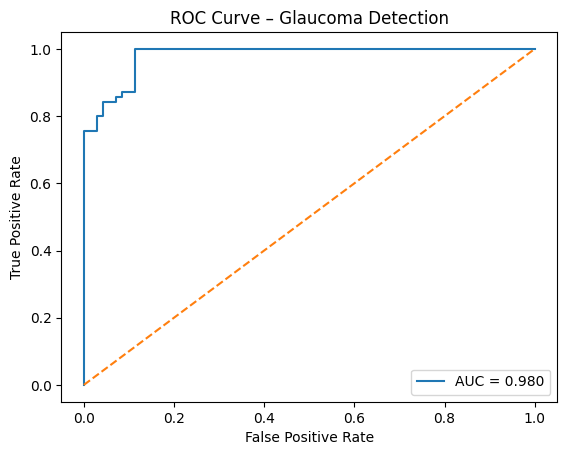

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred):.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Glaucoma Detection")
plt.legend()
plt.show()
